# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean())# Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnostico:**
En el dataframe de "users" se identificaron valores nulos en las columnas "city" y "churn_date". En el caso de "city" el porcentaje de valores nulos es del 11%. Al tratarse de datos categóricos, no tiene sentido imputarlos, por lo que se conservarán los valores como nulos. En el caso de "churn_date", el porcentaje es del 88%, por lo que se recomienda ignorar esta columna.  

En el dataframe de "usage"se ha identificado un 0.1% de valores nulos en la columna "date". Al ser una cantidad insignificante, dejaremos esos valores como nulos, ya que no tiene sentido imputarlos, por tratarse de datos categóricos (en este caso fechas). Por otro lado, las columnas de "duration" y "length" tienen un porcentaje de 55% y 44% de valores nulos. No podemos ignorar estos valores ya que se trata de valores numéricos importantes para el análisis estadístico, por lo que imputaremos usando la mediana o la media, según sean las observaciones que encontremos en la distribución de estas columnas. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:

print("user_id:",users['user_id'].describe())
print()
print("age:", users['age'].describe()) # explorar columnas numéricas de users



user_id: count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

age: count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` no tiene problemas. Los valores registrados de ID van de 10,000 a 13,999 es decir, un total de 4000 Ids.  
- La columna `age` presenta una desviación estándar excesivamente alta (123 en una columna donde el valor maximo es de 79. Esto se debe a que la columna contiene sentinels, tal como revela el valor minimo de -999.

In [13]:


print("id:",usage["id"].describe())
print()
print("user_id:", usage["user_id"].describe())
print()
print("duration:", usage["duration"].describe())
print()
print("length:", usage["length"].describe())



  # explorar columnas numéricas de usage

id: count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

user_id: count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

duration: count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

length: count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


- Las columnas `id` y `user_id` están limpias. No presentan valores extremos o fuera de rango ni tampoco se han detectado sentinels u otros valores inválidos.
- La columna `duration`presenta un total de 17,924 registros, pero esto es de esperar ya que no todos los tipos de comunicación son del tipo de llamada. Habiendo, por ejemplo, mensajes de texto, estos no tendrían una duración que registrar. Por otro lado, la mediana y la media presentan una diferencia de 2 minutos, producto sin duda de valores outliers, siendo el valor máximo de 120 minutos. Tratándose de duración de llamadas telefónicas, 120 minutos es alto en comparación al resto, pero no se considera anormal. Hay personas, aunque sean pocas, que pueden estar en llamadas de larga duración. También se identificó un valor problemático en valor mínimo, el cual indica "0", lo cual no es realista en este caso.
- La columna `length` presenta un total de 22,104 registros que sumados a los de duration, dan el total de 40,000 registros esperados. En general comparte rasgos en comun con la columna de duration, con un outlier alto pero no irreal de 1490, el cual aumenta la media con respecto a la mediana. El valor minimo tambien es de cero, lo cual tampoco es realista en estas circunstancias, aunque puede tratarse de un error de registro. 

In [14]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for c in columnas_user:
    print(f"columna:{c}")
    print(users[c].describe())
    print()
    print(f"Valores únicos en columna:{c}:")
    print(users[c].value_counts(dropna=False))
    print()


columna:city
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

Valores únicos en columna:city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

columna:plan
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

Valores únicos en columna:plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` tiene valores faltantes debido a la presencia de dos de los valores únicos, los cuales son "NaN" y "?"", el cual es un sentinel. Se identificó "Bogotá" como la ciudad con más llamadas registradas, con una frecuencia de 808, seguida de CDMX con 730. 
- La columna `plan` no presenta problemas de ningun tipo. Todos sus valores unicos son correctos y no faltan registros en la columna.  Se identifica el plan basico como el más usado con una frecuencia de 2595 registros. Esto es de esperar. Es interesante señalar que el resto de los registros, que constituyen un 35% aproximadamente del total, sean premium. Esto resulta positivo para la empresa.

In [15]:

# explorar columna categórica de usage
print(usage['type'].describe())
print()
print(f"Valores únicos en columna:")
print(usage['type'].value_counts(dropna=False))

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Valores únicos en columna:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` no presenta irregularidades. Tiene el total esperado de 40.000 registros distribuidos entre mensajes de texto y llamadas, con una frecuencia de 22092 registros de mensajes de texto, indicando un mayor uso de este medio de comunicación que el de las llamadas. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Diagnóstico**

Tras revisar minuciosamente las columnas categoricas y numericas de las fuentes de datos indicadas, se ha observado la presencia de outliers, valores invalidos y sentinels en algunas de ellas. 

La columna "age" del dataset de "users" presenta sentinels con números como "-999". En este caso se recomienda inputar estos registros, reemplazándolos por la mediana ya que la media es 33 pero el percentil 25 es 32, lo cual indica una distorsión por valores extremos, haciendo de la mediana la medida más robusta para este caso.

Las columnas "duration" y "length" del dataset "usage" poseen valores nulos, tienen "0" en los valores mínimos correspondientes. Se recomienda investigar y confirmar si se trata de un error de registro o si el valor "0" indica una ausencia de valores. 

La columna "city" tiene entre sus valores únicos los de "NaN" y "?", siendo este último un sentinel y los primeros una indicación de pandas señalando datos faltantes. Se recomienda convertir los sentinel a NaN para que haya consistencia.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users

users["reg_date"].dt.year.unique()


array([2022, 2026, 2023, 2024])

En `reg_date`, se encontró el año 2026, el cual aún no ha transcurrido y no tiene sentido para efectos de este análisis. 

In [19]:
usage["date"].dt.year.unique() # Revisar los años presentes en `date` de usage


array([2024.,   nan])

En `date`, se encontro solamente el año 2024 y un valor de nan. Si bien corresponde que la fecha de uso sea 2024, ya que el análisis gira en torno a este año, el valor de "nan" es problemático.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En "reg_date" del dataset "users" se encontró el año 2026, el cual es un año sin transcurrir y además no encaja con los propósitos de este análisis correspondiente al 2024. Se recomienda marcar los registros de 2026 como valores nulos. Se pueden conservar los años anteriores a 2024, ya que se trata de fechas de registro de usuarios.

En "date" del dataset de "usage" se encontraron solamente el año 2024 (lo cual es de esperar) y valores "nan". Como estos valores representan solo el 0.125% de la columna, se recomienda ignorarlos. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age

mediana_age = users[users['age'] != -999]['age'].median()

users['age'] = users['age'].replace(-999, mediana_age)

print(users['age'].describe())


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [21]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios

print(f"Valores únicos en City:")
print(users['city'].value_counts(dropna=False))


Valores únicos en City:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
fechas_2026 = users['reg_date'].dt.year == 2026
users.loc[fechas_2026, 'reg_date'] = pd.NaT

# Verificar cambios
años_restantes = users['reg_date'].dropna().dt.year.unique()
print(f"Años válidos restantes: {sorted(años_restantes)}")

Años válidos restantes: [2022, 2023, 2024]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print("Análisis de valores nulos en 'duration' por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))
print()
print("Porcentaje de nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100))

Análisis de valores nulos en 'duration' por tipo:
type
call        0
text    22076
Name: duration, dtype: int64

Porcentaje de nulos en duration por tipo:
type
call     0.000000
text    99.927576
Name: duration, dtype: float64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("Análisis de valores nulos en 'length' por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))
print()
print("Porcentaje de nulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100))

Análisis de valores nulos en 'length' por tipo:
type
call    17896
text        0
Name: length, dtype: int64

Porcentaje de nulos en length por tipo:
type
call    99.932991
text     0.000000
Name: length, dtype: float64


Se confirmaron los valores nulos de `duration` y `length`y se dejan como están debido a que están asociados a los tipos de comunicación. En el caso de las llamadas "lenght" tiene un 99% aproximadamente de valores nulos, debido a que son llamadas y por tanto no se puede medir la "longitud de texto" de este tipo de comunicaciones. Por lo mismo, en el caso de los mensajes de texto "duration" tiene un 99% de valores nulos, debido a que los mensajes de texto tienen longitud de texto pero no tienen "duración". Se recomienda mantener los valores nulos porque representan la estructura natural de los datos. Es decir, que son perfectamente lógicos y no es necesario imputarlos o eliminarlos. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["duration_filled"] = usage["duration"].fillna(0) #para sumar minutos correctamente

# Agrupar información por usuario
usage_agg = usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",        # usar el nombre de la columna como string
    "is_call": "sum",        # usar el nombre de la columna como string  
    "duration_filled": "sum" # sumar la duración total de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration_filled
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration_filled': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()# Resumen estadístico de las columnas numéricas


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

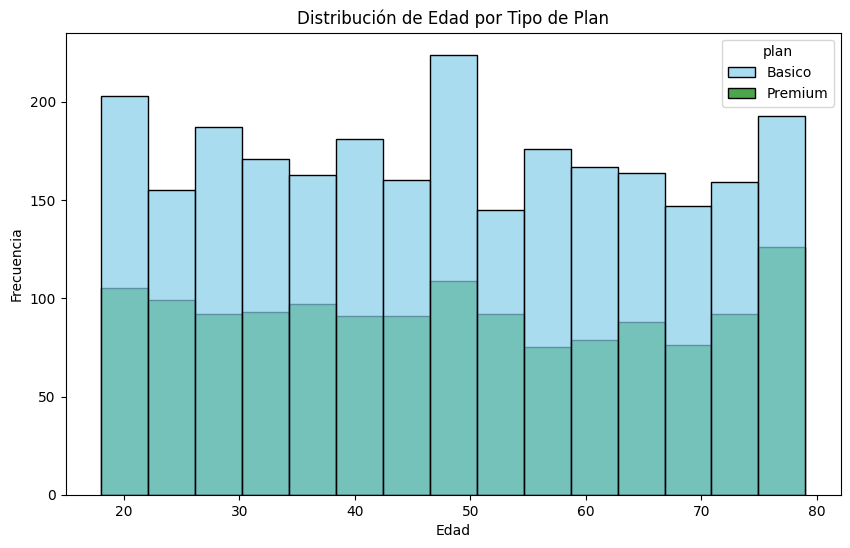

In [30]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan',
             palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 

La distribución de edad muestra un patrón trimodal con tres picos distintivos:

Plan Básico:
- Presenta tres grupos principales: usuarios jóvenes ( alrededor de 20 años), usuarios de mediana edad (48-52 años, el grupo más numeroso), y usuarios mayores ( de 75 a 79 años)

Plan Premium:
- Se concentra principalmente en usuarios de mayor edad (75-79 años), sugiriendo que este segmento demográfico prefiere las funcionalidades premium"

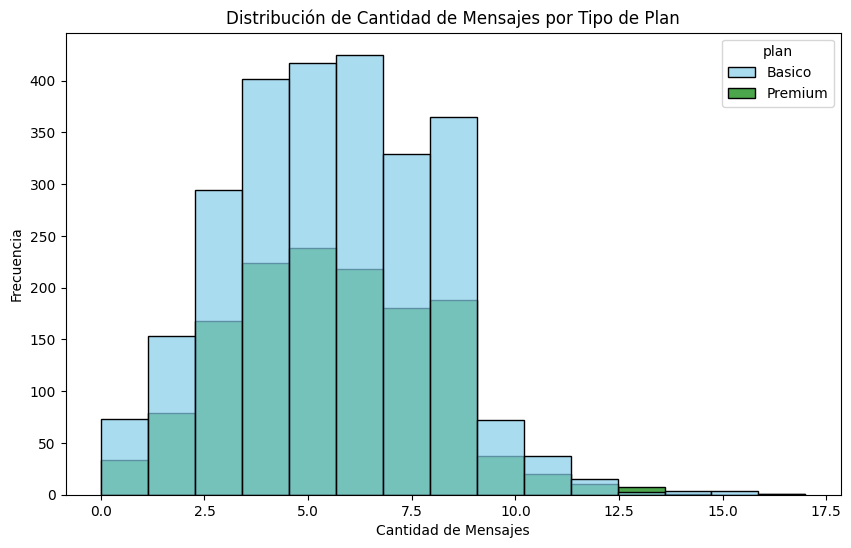

In [31]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 


- El patrón del histograma muestra un sesgo a la derecha, lo cual es de esperar dada la presencia de outliers (algunos usuarios llegan a tener hasta 17 mensajes).
- En el plan básico la distribución tiene un pico entre 6 y 7 mensajes, mientras que en el plan premium, la distribución se concentra alrededor del envío de 5 mensajes. 



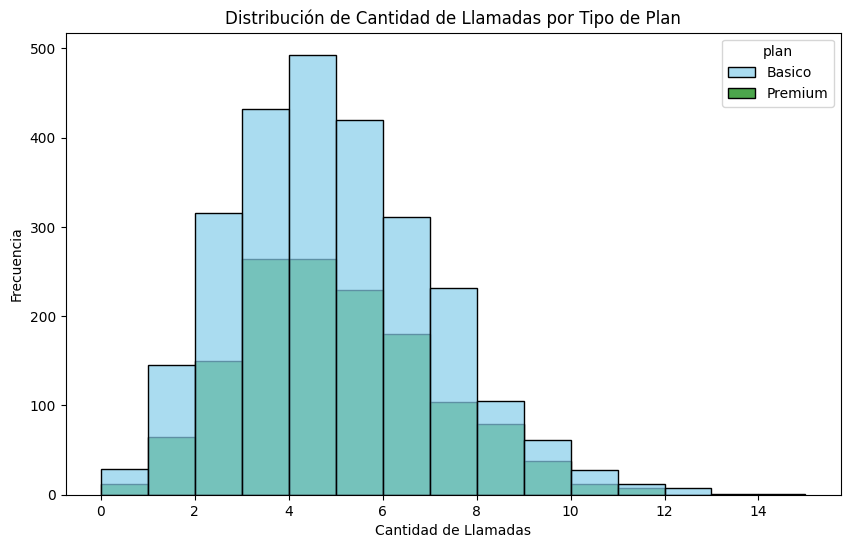

In [32]:

# Histograma para visualizar la cant_llamadas


plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
             palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()





💡Insights: 
- El patrón del histograma muestra un sesgo a la derecha, lo cual es de esperar dada la presencia de outliers (algunos usuarios llegan a tener hasta 14 llamadas).
- En el plan básico la distribución tiene un pico entre 4 y 5 llamadas, mientras que en el plan premium, la distribución se concentra alrededor de las 3 a 5 llamadas. 

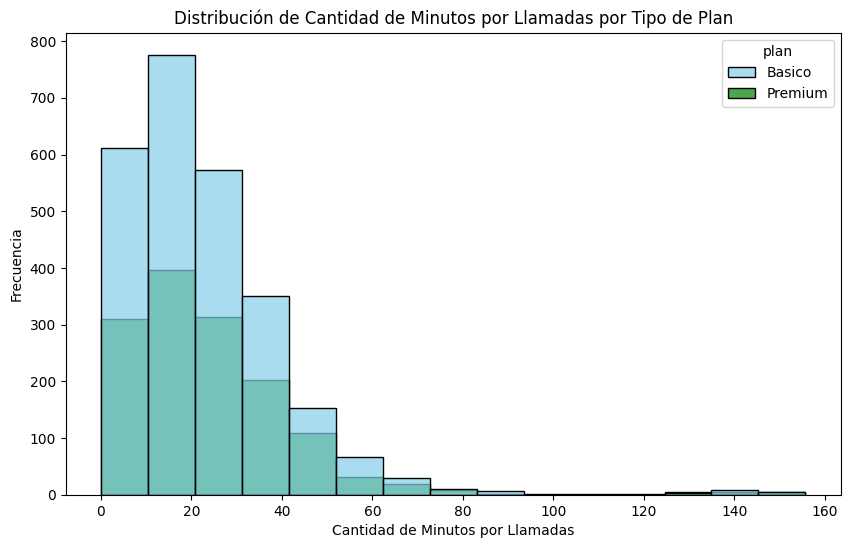

In [33]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Minutos por Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Minutos por Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡El patrón del histograma muestra un amplio sesgo a la derecha, lo cual es de esperar dada la presencia de outliers (algunos usuarios llegan a tener llamadas de hasta 150 minutos de duración aproximadamente).
Tanto el plan básico como el plan premium tienen un pico en cuanto a duración de llamadas de alrededor de 10 a poco más de 20 minutos.
 


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

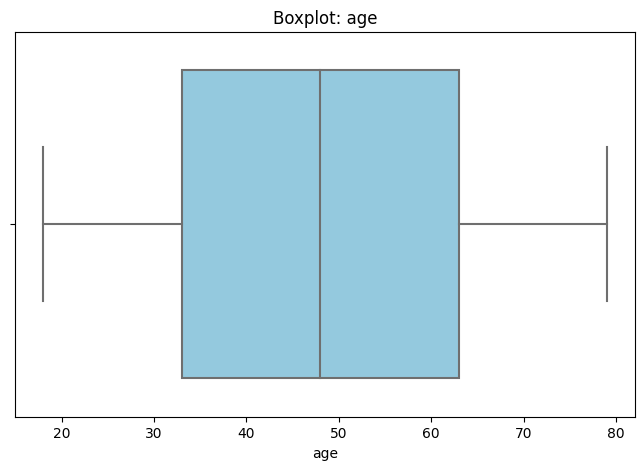

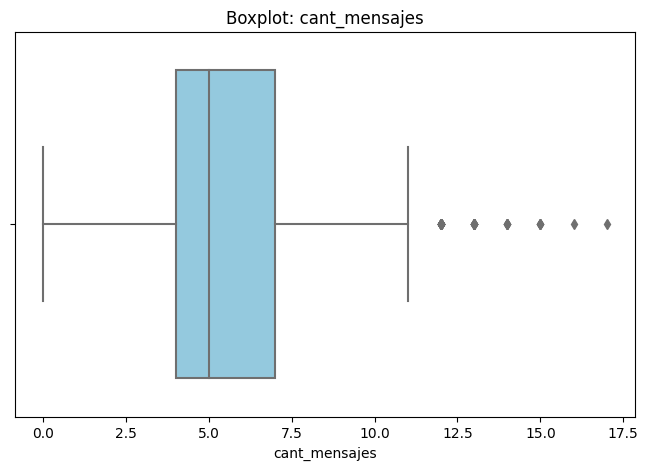

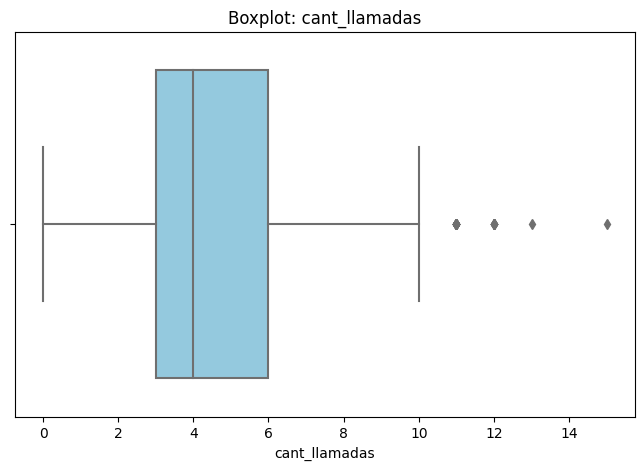

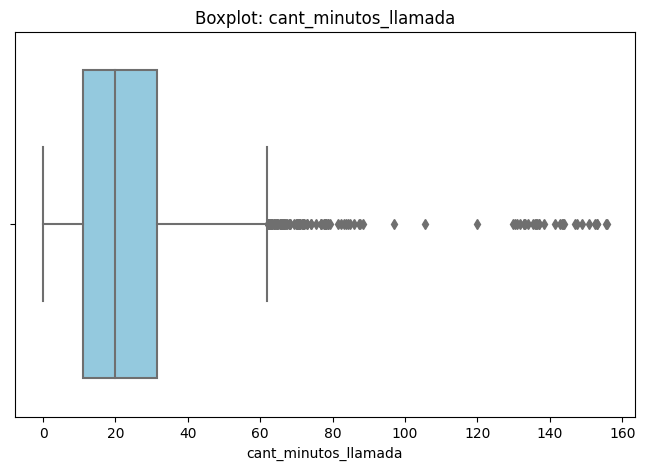

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for c in columnas_numericas:  # Itera sobre los nombres
    plt.figure(figsize=(8, 5))  # Opcional: tamaño del gráfico
    sns.boxplot(x=user_profile[c], color='skyblue')
    plt.title(f'Boxplot: {c}')  # Opcional: título dinámico
    plt.xlabel(c)
    plt.show()


💡Insights: 
- Age: presenta valores extremos pero no outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta un alto nivel de outliers

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"\n{col}:")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo actual: {user_profile[col].max()}")
    print(f"Outliers superiores: {(user_profile[col] > limite_superior).sum()}")




cant_mensajes:
Límite superior: 11.50
Valor máximo actual: 17.0
Outliers superiores: 46

cant_llamadas:
Límite superior: 10.50
Valor máximo actual: 15.0
Outliers superiores: 30

cant_minutos_llamada:
Límite superior: 61.86
Valor máximo actual: 155.69
Outliers superiores: 109


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


###### 💡Insights: 
- cant_mensajes: Mantener outliers. El motivo es que 45 usuarios de un total de 4000, significan un 1.15% del total. Si bien se trata de casos atípicos, no son irreales. Puede tratarse de personas con una clara preferencia por los mensajes a cualquier otra forma de comunicación. 
- cant_llamadas: Mantener outliers. El motivo es que 30 usuarios de un total de 4000, significan un 0.75% del total. Si bien se trata de casos atípicos, no son irreales.Puede tratarse de individuos cuyo trabajo o vida social involucra muchas llamadas. 
- cant_minutos_llamada: Mantener outliers. El motivo es que 109 outliers de un total de 4000 usuarios, solo constituyen el 2.73% del total. Se trata de casos atípicos, pero reales. Puede tratarse de individuos que simplemente disfrutan hablar por teléfono, como personas mayores comunicándose con parientes a distancia. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:

# Crear columna grupo_uso
conditions = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
choices = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(conditions, choices, default='Alto uso')


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
conditions = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
choices = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(conditions, choices, default='Adulto Mayor')


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
# Visualización de los segmentos por uso
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 6))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 6))
sns.countplot(data=user_profile, x='grupo_edad', palette='plasma')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna age del dataframe “users” presentaba valores sentinel (-999), de los cuales existían 55 registros. Los valores sentinel fueron reemplazados por la mediana.  
- Se identificó un total de 14.12% de valores nulos entre valores NaN y sentinels (“?”) en la columna “city” del dataframe “users”. Los sentines fueron convertidos en valores nulos reales. Al tratarse de datos categóricos, no es posible imputarlos. Se conservan como están y se recomienda revisar los procesos de registro de datos. 
- Se identificó un 88% de valores nulos en la columna “churn_date” del dataframe. Sin embargo, como esta columna no es relevante para el análisis, se optó por ignorarla, pero se recomienda una revisión a fondo del proceso llevado a cabo para los registros de estos datos en particular. 
- Las columnas de "duration" y "length" del dataframe “usage” tienen un porcentaje de 55% y 44% de valores nulos respectivamente. Sin embargo, se descubrió que esto está asociado con el tipo de comunicaciones. Las llamadas tienen registros de “length” pese a que no hay textos para registrar y los mensajes de texto, tienen registros de “duration” pese a que los mensajes de texto no tienen duración registrable. Se conservan estos valores nulos por considerarse como lógicos dentro de este contexto.
- La columna de “reg_date” del dataframe “users” no tenía el formato apropiado para fecha y el 1% de sus registros era de una fecha inválida (2026). Se realizó la conversión de la columna al formato apropiado y se marcaron las fechas inválidas como NA. Se recomienda revisar el proceso de registro de datos para futuras referencias.  

  


🔍 **Segmentos por Edad**
- Al segmentar a los usuarios por edad, se identificó que la mayoría de los usuarios se encuentra en edad adulta, entre los 30 y los 59 años, seguidos por los mayores de edad y curiosamente con los jóvenes constituyendo el segmento más pequeño. 


📊 **Segmentos por Nivel de Uso**
- En general, los usuarios dan un uso medio a sus llamadas y mensajes (entre 5 y 9 de cada uno) o utilizan poco los servicios. El segmento más bajo lo constituyen los que le dan más uso, aunque esto es normal ya que como se pudo observar anteriormente, muchos de los outliers identificados son justamente usuarios con una cantidad de llamadas y/o mensajes superior a lo normal. 


➡️ En general, se puede concluir que la mayoría de los usuarios son adultos que dan un uso regular a sus planes de llamadas y mensajes. Además, la información anterior sugiere que existe entre los usuarios jóvenes una falta de recursos que les permitan acceder a los servicios de la empresa, lo cual explica su escasa presencia entre el número de usuarios de la empresa. 


💡 **Recomendaciones**
- Los usuarios de alto uso y los jóvenes representan oportunidades comerciales. Los usuarios de alto uso representan a la mayoría de los outliers y aunque son atípicos, está claro que hacen gran uso de los servicios de la empresa. Se recomienda enfocar esfuerzos para convertir a los usuarios de este segmento en usuarios premium, quizás incrementando el número de llamadas y mensajes que este servicio ofrece.
- También se recomienda crear nuevos planes más baratos para los jóvenes, planes accesibles que permitan a la empresa aumentar la clientela en este segmento. Tal vez ofrecer opciones para estudiantes o planes familiares donde los adultos puedan incluir a sus hijos.
- También se ha observado que los mayores de edad tienden a ser el grupo más numeroso de usuarios de plan Premium. Se sugiere ofrecer servicios adicionales, como por ejemplo una atención al cliente más personalizada (entrenada para tratar con mayores de edad, quienes se sabe a menudo experimentan problemas con la tecnología) para aumentar la retención de clientes premium en este grupo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`